# Preprocessing

In [2]:
%pip install pandas openpyxl
%pip install matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
import re
import os

# Deteksi Environment
if 'google.colab' in sys.modules:
    from google.colab import files
    print('Environment: Google Colab')
else:
    print('Environment: Lokal / Antigravity')

import pandas as pd
print('Semua library berhasil di-import')


Environment: Lokal / Antigravity
Semua library berhasil di-import


In [4]:
import sys
if 'google.colab' in sys.modules:
    uploaded = files.upload()
    nama_file = list(uploaded.keys())[0]
else:
    # Menggunakan dataset lokal
    nama_file = '../data/List Cafe.xlsx'
    print(f'Menggunakan file lokal: {nama_file}')

df = pd.read_excel(nama_file)
print(f'Data berhasil dimuat: {df.shape[0]} baris')
df.head()


Menggunakan file lokal: ../data/List Cafe.xlsx
Data berhasil dimuat: 112 baris


,No,Nama,Alamat,Lokasi,Harga Menu,Variasi Menu,Rating,Jarak,Fasilitas,Jam Operasional,Nomor
0,1,KAF Cafe,"Jl. MT. Haryono No.127, Ketawanggede, Kec. Low...",https://maps.app.goo.gl/3frkhJY4DwpKhMFA8?g_st=aw,Rp25.000-50.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snack...,"4,4",550m,- Indoor (AC)\n- Semi-outdoor\n- Outdoor\n- Sh...,08.00 - 03.00,NaN
1,2,Nakoa Cafe Suhat,"Jl. Puncak Borobudur Blok G No.502, Mojolangu,...",https://maps.app.goo.gl/qUHtaC14v7B2tQFC9?g_st=aw,Rp25.000-50.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snack...,"4,8","2,1 km",- Indoor (AC)\n- Semi-outdoor\n- Outdoor\n- Mu...,09.00 - 00.00,0822-2345-1237
2,3,Nakoa Cafe Panjaitan,"Jl. Mayjend Panjaitan No.75, Penanggungan, Kec...",https://maps.app.goo.gl/dKmW9vcaj1dJvKLU9?g_st=aw,Rp25.000-50.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snack...,"4,9","1,4 km",- Indoor (AC)\n- Semi-outdoor\n- Outdoor\n- So...,09.00 - 00.00,0822-2345-1237
3,4,Semusim Cafe,"Jl. MT. Haryono No.110, Ketawanggede, Kec. Low...",https://maps.app.goo.gl/Lau5txSnnnQEsZqh7?g_st=aw,Rp1-25.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snack...,"4,5",600m,- Indoor (AC)\n- Semi-outdoor\n- Working Space...,07.00 - 02.00,NaN
4,5,Roketto Coffee & Co,"Jl. Kendalsari No.06, Jatimulyo, Kec. Lowokwar...",https://maps.app.goo.gl/NJSvUHjD7pi2EpgH9?g_st=aw,Rp25.000-50.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snacks,"4,5","1,3 km","Indoor (AC),\nSemi-outdoor,\nOutdoor, Mushola,...",24 Jam,NaN


Import Library

In [5]:
import sys
import re
import os

# Deteksi Environment
if 'google.colab' in sys.modules:
    from google.colab import files
    print('Environment: Google Colab')
else:
    print('Environment: Lokal / Antigravity')

import pandas as pd
print('Semua library berhasil di-import')


Environment: Lokal / Antigravity
Semua library berhasil di-import


Load Dataset

In [6]:
import sys
if 'google.colab' in sys.modules:
    uploaded = files.upload()
    nama_file = list(uploaded.keys())[0]
else:
    # Menggunakan dataset lokal
    nama_file = '../data/List Cafe.xlsx'
    print(f'Menggunakan file lokal: {nama_file}')

df = pd.read_excel(nama_file)
print(f'Data berhasil dimuat: {df.shape[0]} baris')
df.head()


Menggunakan file lokal: ../data/List Cafe.xlsx
Data berhasil dimuat: 112 baris


,No,Nama,Alamat,Lokasi,Harga Menu,Variasi Menu,Rating,Jarak,Fasilitas,Jam Operasional,Nomor
0,1,KAF Cafe,"Jl. MT. Haryono No.127, Ketawanggede, Kec. Low...",https://maps.app.goo.gl/3frkhJY4DwpKhMFA8?g_st=aw,Rp25.000-50.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snack...,"4,4",550m,- Indoor (AC)\n- Semi-outdoor\n- Outdoor\n- Sh...,08.00 - 03.00,NaN
1,2,Nakoa Cafe Suhat,"Jl. Puncak Borobudur Blok G No.502, Mojolangu,...",https://maps.app.goo.gl/qUHtaC14v7B2tQFC9?g_st=aw,Rp25.000-50.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snack...,"4,8","2,1 km",- Indoor (AC)\n- Semi-outdoor\n- Outdoor\n- Mu...,09.00 - 00.00,0822-2345-1237
2,3,Nakoa Cafe Panjaitan,"Jl. Mayjend Panjaitan No.75, Penanggungan, Kec...",https://maps.app.goo.gl/dKmW9vcaj1dJvKLU9?g_st=aw,Rp25.000-50.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snack...,"4,9","1,4 km",- Indoor (AC)\n- Semi-outdoor\n- Outdoor\n- So...,09.00 - 00.00,0822-2345-1237
3,4,Semusim Cafe,"Jl. MT. Haryono No.110, Ketawanggede, Kec. Low...",https://maps.app.goo.gl/Lau5txSnnnQEsZqh7?g_st=aw,Rp1-25.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snack...,"4,5",600m,- Indoor (AC)\n- Semi-outdoor\n- Working Space...,07.00 - 02.00,NaN
4,5,Roketto Coffee & Co,"Jl. Kendalsari No.06, Jatimulyo, Kec. Lowokwar...",https://maps.app.goo.gl/NJSvUHjD7pi2EpgH9?g_st=aw,Rp25.000-50.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snacks,"4,5","1,3 km","Indoor (AC),\nSemi-outdoor,\nOutdoor, Mushola,...",24 Jam,NaN


Deduplikasi Data

In [7]:
print("Jumlah baris sebelum deduplikasi:", len(df))
df = df.drop_duplicates(subset='Nama', keep='first').reset_index(drop=True)
print("Jumlah baris setelah deduplikasi :", len(df))
print("Total cafe unik:", df['Nama'].nunique())

Jumlah baris sebelum deduplikasi: 112
Jumlah baris setelah deduplikasi : 110
Total cafe unik: 110


Cleaning strip spasi & nama kolom

In [8]:
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
df.columns = df.columns.str.strip()

print("Cleaning dasar selesai")
df.head()

Cleaning dasar selesai


,No,Nama,Alamat,Lokasi,Harga Menu,Variasi Menu,Rating,Jarak,Fasilitas,Jam Operasional,Nomor
0,1,KAF Cafe,"Jl. MT. Haryono No.127, Ketawanggede, Kec. Low...",https://maps.app.goo.gl/3frkhJY4DwpKhMFA8?g_st=aw,Rp25.000-50.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snack...,"4,4",550m,- Indoor (AC)\n- Semi-outdoor\n- Outdoor\n- Sh...,08.00 - 03.00,NaN
1,2,Nakoa Cafe Suhat,"Jl. Puncak Borobudur Blok G No.502, Mojolangu,...",https://maps.app.goo.gl/qUHtaC14v7B2tQFC9?g_st=aw,Rp25.000-50.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snack...,"4,8","2,1 km",- Indoor (AC)\n- Semi-outdoor\n- Outdoor\n- Mu...,09.00 - 00.00,0822-2345-1237
2,3,Nakoa Cafe Panjaitan,"Jl. Mayjend Panjaitan No.75, Penanggungan, Kec...",https://maps.app.goo.gl/dKmW9vcaj1dJvKLU9?g_st=aw,Rp25.000-50.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snack...,"4,9","1,4 km",- Indoor (AC)\n- Semi-outdoor\n- Outdoor\n- So...,09.00 - 00.00,0822-2345-1237
3,4,Semusim Cafe,"Jl. MT. Haryono No.110, Ketawanggede, Kec. Low...",https://maps.app.goo.gl/Lau5txSnnnQEsZqh7?g_st=aw,Rp1-25.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snack...,"4,5",600m,- Indoor (AC)\n- Semi-outdoor\n- Working Space...,07.00 - 02.00,NaN
4,5,Roketto Coffee & Co,"Jl. Kendalsari No.06, Jatimulyo, Kec. Lowokwar...",https://maps.app.goo.gl/NJSvUHjD7pi2EpgH9?g_st=aw,Rp25.000-50.000,- Coffee\n- Non-Coffee\n- Main Course\n- Snacks,"4,5","1,3 km","Indoor (AC),\nSemi-outdoor,\nOutdoor, Mushola,...",24 Jam,NaN


Konversi Rating Ke Float

In [9]:
df['Rating'] = df['Rating'].astype(str).str.replace(',', '.').astype(float)
print("✅ Rating sudah dikonversi ke float")
df[['Nama', 'Rating']].head()

✅ Rating sudah dikonversi ke float


,Nama,Rating
0,KAF Cafe,4.4
1,Nakoa Cafe Suhat,4.8
2,Nakoa Cafe Panjaitan,4.9
3,Semusim Cafe,4.5
4,Roketto Coffee & Co,4.5


Konversi Jarak ke Kilometer

In [10]:
def parse_jarak(val):
    if pd.isna(val):
        return None
    val = str(val).strip().lower().replace(',', '.')
    if 'm' in val and 'km' not in val:
        angka = re.findall(r'[\d.]+', val)
        return round(float(angka[0]) / 1000, 2) if angka else None
    else:
        angka = re.findall(r'[\d.]+', val)
        return round(float(angka[0]), 2) if angka else None

df['Jarak_km'] = df['Jarak'].apply(parse_jarak)
print("✅ Jarak sudah dikonversi ke km")
df[['Nama', 'Jarak', 'Jarak_km']].head(10)

✅ Jarak sudah dikonversi ke km


,Nama,Jarak,Jarak_km
0,KAF Cafe,550m,0.55
1,Nakoa Cafe Suhat,"2,1 km",2.10
2,Nakoa Cafe Panjaitan,"1,4 km",1.40
3,Semusim Cafe,600m,0.60
4,Roketto Coffee & Co,"1,3 km",1.30
5,Pesenkopi Plus Betek,800m,0.80
6,Swara Bungur,"2,7 km",2.70
7,Hambee coffee,"1,6 km",1.60
8,mao.place,"1,5 km",1.50
9,House Of Tjandu,1 km,1.00


Konversi Harga ke Midpoint

In [11]:
def parse_harga(val):
    if pd.isna(val):
        return None
    val = str(val).upper().replace('RP', '').replace('RP.', '')
    val = val.replace('.', '').replace(' ', '')
    angka = re.findall(r'\d+', val)
    angka = [int(x) for x in angka]
    angka = [x * 1000 if x < 1000 else x for x in angka]
    if len(angka) >= 2:
        return round((angka[0] + angka[1]) / 2 / 1000, 1)
    elif len(angka) == 1:
        return round(angka[0] / 1000, 1)
    return None

df['Harga_Midpoint'] = df['Harga Menu'].apply(parse_harga)
print("✅ Harga sudah dikonversi ke Midpoint")
df[['Nama', 'Harga Menu', 'Harga_Midpoint']].head(10)

✅ Harga sudah dikonversi ke Midpoint


,Nama,Harga Menu,Harga_Midpoint
0,KAF Cafe,Rp25.000-50.000,37.5
1,Nakoa Cafe Suhat,Rp25.000-50.000,37.5
2,Nakoa Cafe Panjaitan,Rp25.000-50.000,37.5
3,Semusim Cafe,Rp1-25.000,13.0
4,Roketto Coffee & Co,Rp25.000-50.000,37.5
5,Pesenkopi Plus Betek,Rp25.000-50.000,37.5
6,Swara Bungur,Rp1-25.000,13.0
7,Hambee coffee,Rp1-25.000,13.0
8,mao.place,Rp25.000-50.000,37.5
9,House Of Tjandu,Rp25.000-50.000,37.5


Encoding Fasilitas (Binary)

In [12]:
def encode_fasilitas(val):
    if pd.isna(val):
        return {}
    v = str(val).lower()
    return {
        'has_WiFi':          1 if re.search(r'wi.?fi|wifi', v) else 0,
        'has_AC':            1 if re.search(r'\bac\b', v) else 0,
        'has_Parkir':        1 if re.search(r'parkir', v) else 0,
        'has_Mushola':       1 if re.search(r'mushol', v) else 0,
        'has_Toilet':        1 if re.search(r'toilet', v) else 0,
        'has_Colokan':       1 if re.search(r'colokan|stopkontak|stop kontak', v) else 0,
        'has_Outdoor':       1 if re.search(r'outdoor', v) else 0,
        'has_Smoking_Area':  1 if re.search(r'smok|smoking', v) else 0,
        'has_Working_Space': 1 if re.search(r'working|work space|social space', v) else 0,
        'has_Indoor':        1 if re.search(r'indoor', v) else 0,
    }

fasilitas_encoded = df['Fasilitas'].apply(encode_fasilitas).apply(pd.Series)
df = pd.concat([df, fasilitas_encoded], axis=1)

print("✅ Fasilitas sudah di-encode dengan prefix 'has_'")
df[['Nama', 'has_WiFi', 'has_AC', 'has_Parkir', 'has_Mushola']].head()

✅ Fasilitas sudah di-encode dengan prefix 'has_'


,Nama,has_WiFi,has_AC,has_Parkir,has_Mushola
0,KAF Cafe,1,1,1,1
1,Nakoa Cafe Suhat,1,1,1,1
2,Nakoa Cafe Panjaitan,1,1,1,1
3,Semusim Cafe,1,1,1,1
4,Roketto Coffee & Co,1,1,1,1


Tambah Fitur Jumlah Fasilitas & Jumlah Menu

In [13]:
df['Jumlah_Fasilitas'] = df[['has_WiFi','has_AC','has_Indoor','has_Parkir',
                             'has_Mushola','has_Toilet','has_Colokan',
                             'has_Outdoor','has_Smoking_Area',
                             'has_Working_Space']].sum(axis=1)

def hitung_menu(val):
    if pd.isna(val):
        return 0
    items = re.split(r'\n|,', str(val))
    return len([i for i in items if i.strip().replace('-', '').strip() != ''])

df['Jumlah_Menu'] = df['Variasi Menu'].apply(hitung_menu)

print("✅ Fitur Jumlah_Fasilitas dan Jumlah_Menu sudah ditambahkan")
df[['Nama', 'Jumlah_Fasilitas', 'Jumlah_Menu']].head(10)

✅ Fitur Jumlah_Fasilitas dan Jumlah_Menu sudah ditambahkan


,Nama,Jumlah_Fasilitas,Jumlah_Menu
0,KAF Cafe,8,5
1,Nakoa Cafe Suhat,8,4
2,Nakoa Cafe Panjaitan,9,4
3,Semusim Cafe,10,5
4,Roketto Coffee & Co,8,4
5,Pesenkopi Plus Betek,8,5
6,Swara Bungur,8,5
7,Hambee coffee,8,4
8,mao.place,7,3
9,House Of Tjandu,8,4


Hitung Durasi Buka (Jam Operasional)

In [14]:
def hitung_durasi(val):
    if pd.isna(val):
        return None
    val = str(val).strip().lower()
    if '24' in val and ('jam' in val or 'hour' in val or '00.00' in val or val == '24'):
        return 24
    val = re.sub(r'\(.*?\)', '', val).strip()
    def parse_waktu(s):
        s = s.strip()
        is_am = 'am' in s
        is_pm = 'pm' in s
        s = s.replace('am', '').replace('pm', '').strip()
        s = s.replace('.', ':')
        parts = s.split(':')
        try:
            jam = int(parts[0])
            menit = int(parts[1]) if len(parts) > 1 else 0
        except:
            return None
        if is_pm and jam != 12:
            jam += 12
        if is_am and jam == 12:
            jam = 0
        return jam + menit / 60
    for sep in ['–', '-', '−']:
        if sep in val:
            parts = val.split(sep)
            if len(parts) == 2:
                buka = parse_waktu(parts[0])
                tutup = parse_waktu(parts[1])
                if buka is None or tutup is None:
                    return None
                if tutup <= buka:
                    tutup += 24
                return round(tutup - buka, 1)
    return None

df['Durasi_Buka'] = df['Jam Operasional'].apply(hitung_durasi)
print("✅ Durasi Buka sudah dihitung")
df[['Nama', 'Jam Operasional', 'Durasi_Buka']].head(15)

✅ Durasi Buka sudah dihitung


,Nama,Jam Operasional,Durasi_Buka
0,KAF Cafe,08.00 - 03.00,19.0
1,Nakoa Cafe Suhat,09.00 - 00.00,15.0
2,Nakoa Cafe Panjaitan,09.00 - 00.00,15.0
3,Semusim Cafe,07.00 - 02.00,19.0
4,Roketto Coffee & Co,24 Jam,24.0
5,Pesenkopi Plus Betek,11.00 - 23.45,12.8
6,Swara Bungur,24 Jam,24.0
7,Hambee coffee,08.00 - 22.00,14.0
8,mao.place,11.00 - 23.00,12.0
9,House Of Tjandu,10.00 - 22.00,12.0


Buat Kategori Harga & Jarak

In [15]:
df['price_category'] = pd.cut(df['Harga_Midpoint'],
                              bins=[0, 25, 50, 200],
                              labels=['Low', 'Medium', 'High'])

df['distance_category'] = pd.cut(df['Jarak_km'],
                                 bins=[0, 1, 3, 10],
                                 labels=['Sangat Dekat', 'Dekat', 'Jauh'])

print("✅ Kategori Harga dan Jarak sudah ditambahkan")
df[['Nama', 'Harga_Midpoint', 'price_category', 'Jarak_km', 'distance_category']].head(10)

✅ Kategori Harga dan Jarak sudah ditambahkan


,Nama,Harga_Midpoint,price_category,Jarak_km,distance_category
0,KAF Cafe,37.5,Medium,0.55,Sangat Dekat
1,Nakoa Cafe Suhat,37.5,Medium,2.10,Dekat
2,Nakoa Cafe Panjaitan,37.5,Medium,1.40,Dekat
3,Semusim Cafe,13.0,Low,0.60,Sangat Dekat
4,Roketto Coffee & Co,37.5,Medium,1.30,Dekat
5,Pesenkopi Plus Betek,37.5,Medium,0.80,Sangat Dekat
6,Swara Bungur,13.0,Low,2.70,Dekat
7,Hambee coffee,13.0,Low,1.60,Dekat
8,mao.place,37.5,Medium,1.50,Dekat
9,House Of Tjandu,37.5,Medium,1.00,Sangat Dekat


Handle Missing Value (NaN)

In [16]:
df['Durasi_Buka'] = df['Durasi_Buka'].fillna(12.0)

print("Jumlah NaN setelah diisi:")
print(df[['Durasi_Buka']].isnull().sum())

Jumlah NaN setelah diisi:
Durasi_Buka    0
dtype: int64


Buat DataFrame Final (df_model)

In [17]:
# kolom yang akan digunakan untuk modeling
df_model = df[['Nama', 'Rating', 'Jarak_km', 'Harga_Midpoint',
               'Jumlah_Fasilitas', 'Jumlah_Menu', 'Durasi_Buka',
               'has_WiFi', 'has_AC', 'has_Indoor', 'has_Parkir',
               'has_Mushola', 'has_Toilet', 'has_Colokan',
               'has_Outdoor', 'has_Smoking_Area', 'has_Working_Space',
               'price_category', 'distance_category']].copy()

print("✅ df_model siap digunakan untuk modeling")
print("Jumlah kolom:", len(df_model.columns))
print("Kolom yang ada:", df_model.columns.tolist())

✅ df_model siap digunakan untuk modeling
Jumlah kolom: 19
Kolom yang ada: ['Nama', 'Rating', 'Jarak_km', 'Harga_Midpoint', 'Jumlah_Fasilitas', 'Jumlah_Menu', 'Durasi_Buka', 'has_WiFi', 'has_AC', 'has_Indoor', 'has_Parkir', 'has_Mushola', 'has_Toilet', 'has_Colokan', 'has_Outdoor', 'has_Smoking_Area', 'has_Working_Space', 'price_category', 'distance_category']


In [18]:
df_model.loc[df_model['Jarak_km'] == 0, 'distance_category'] = 'Sangat Dekat'

Cek Final & Simpan File

In [19]:
import sys

# cek NaN terakhir
print("Jumlah NaN di df_model:")
print(df_model.isnull().sum())

filename = "List_Cafe_Model_Final.xlsx"

if 'google.colab' in sys.modules:
    
    df_model.to_excel(filename, index=False)
    from google.colab import files
    files.download(filename)
    print("File didownload dari Colab.")
else:
    
    save_path = f"../data/{filename}"
    df_model.to_excel(save_path, index=False)
    print(f"File berhasil disimpan secara lokal di: {save_path}")

print("Preprocessing SELESAI! File siap untuk Forward Chaining, Backward Chaining, Bayes, dan Certainty Factor.")


Jumlah NaN di df_model:
Nama                 0
Rating               0
Jarak_km             0
Harga_Midpoint       0
Jumlah_Fasilitas     0
Jumlah_Menu          0
Durasi_Buka          0
has_WiFi             0
has_AC               0
has_Indoor           0
has_Parkir           0
has_Mushola          0
has_Toilet           0
has_Colokan          0
has_Outdoor          0
has_Smoking_Area     0
has_Working_Space    0
price_category       0
distance_category    0
dtype: int64
File berhasil disimpan secara lokal di: ../data/List_Cafe_Model_Final.xlsx
Preprocessing SELESAI! File siap untuk Forward Chaining, Backward Chaining, Bayes, dan Certainty Factor.


# Forward Chaining

Rule

In [20]:
rules = [
    {
        'id': 'R1',
        'kondisi': lambda r: r['Jarak_km'] <= 1.5 and r['has_WiFi'] == 1 and r['has_Colokan'] == 1,
        'kesimpulan': 'Cocok untuk nongkrong dekat kampus'
    },
    {
        'id': 'R2',
        'kondisi': lambda r: r['Harga_Midpoint'] <= 25 and r['has_Colokan'] == 1 and r['Rating'] >= 4.3,
        'kesimpulan': 'Cocok untuk mahasiswa budget'
    },
    {
        'id': 'R3',
        'kondisi': lambda r: r['has_WiFi'] == 1 and r['has_Colokan'] == 1 and r['has_AC'] == 1 and r['Jarak_km'] <= 3.0 and r['Harga_Midpoint'] <= 37.5,
        'kesimpulan': 'Cocok untuk belajar/kerja'
    },
    {
        'id': 'R4',
        'kondisi': lambda r: r['Durasi_Buka'] >= 18 and r['has_WiFi'] == 1 and r['has_Colokan'] == 1,
        'kesimpulan': 'Cocok untuk begadang/malam'
    },
    {
        'id': 'R5',
        'kondisi': lambda r: r['has_Outdoor'] == 1 and r['Rating'] >= 4.3 and r['has_Colokan'] == 1,
        'kesimpulan': 'Cocok untuk nongkrong santai outdoor'
    },
    {
        'id': 'R6',
        'kondisi': lambda r: r['Jarak_km'] <= 2.0 and r['Harga_Midpoint'] <= 25 and r['has_WiFi'] == 1 and r['has_Colokan'] == 1,
        'kesimpulan': 'Cocok untuk mahasiswa (dekat + murah)'
    },
    {
        'id': 'R7',
        'kondisi': lambda r: r['Jumlah_Fasilitas'] >= 7 and r['Harga_Midpoint'] <= 37.5 and r['has_Colokan'] == 1,
        'kesimpulan': 'Cocok untuk fasilitas lengkap terjangkau'
    },
    {
        'id': 'R8',
        'kondisi': lambda r: r['Rating'] >= 4.7 and r['Harga_Midpoint'] <= 37.5 and r['has_Colokan'] == 1,
        'kesimpulan': 'Cocok untuk prioritas kualitas'
    },
    {
        'id': 'R9',
        'kondisi': lambda r: r['Jarak_km'] <= 1.5 and r['Harga_Midpoint'] <= 25 and r['has_WiFi'] == 1 and r['has_Colokan'] == 1,
        'kesimpulan': 'Cocok untuk mahasiswa (dekat + murah + wifi)'
    },
    {
        'id': 'R10',
        'kondisi': lambda r: r['Durasi_Buka'] == 24 and r['Harga_Midpoint'] <= 37.5 and r['has_Colokan'] == 1,
        'kesimpulan': 'Cocok untuk cafe 24 jam terjangkau'
    },
    {
        'id': 'R11',
        'kondisi': lambda r: r['Jumlah_Menu'] >= 5 and r['Harga_Midpoint'] <= 37.5 and r['has_Colokan'] == 1,
        'kesimpulan': 'Cocok untuk makan + nongkrong (menu lengkap)'
    },
    {
        'id': 'R12',
        'kondisi': lambda r: r['Jarak_km'] <= 2.0 and r['Harga_Midpoint'] <= 25 and r['Jumlah_Menu'] >= 4 and r['has_Colokan'] == 1,
        'kesimpulan': 'Paket lengkap mahasiswa (dekat + murah + menu variatif)'
    }
]

In [21]:
def forward_chaining(row):
    hasil = []

    for rule in rules:
        if rule['kondisi'](row):
            hasil.append(f"{rule['id']}: {rule['kesimpulan']}")

    return hasil if hasil else ['Tidak memenuhi rule khusus']

In [22]:
df_model['Kategori_FC'] = df_model.apply(
    lambda row: ' | '.join(forward_chaining(row)), axis=1
)

print(df_model[['Nama', 'Kategori_FC']].to_string())

                                          Nama                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       Kategori_FC
0                                     KAF Cafe                                                                                                                                                                                                                                             R1: Cocok untuk nongkrong dekat kampus | R3: Cocok untuk belajar/kerja | R4: Cocok untuk begadang/malam | R5: Cocok untuk nongkrong santai outdoor | R7: Cocok untuk fasilitas lengkap terja

# Backward chaining

In [23]:
goals = {
    'WFH_Kerja': {
        'deskripsi': 'Direkomendasikan untuk WFH / kerja (butuh WiFi, colokan, AC, dan nyaman)',
        'kondisi': lambda r: r['has_WiFi'] == 1 and r['has_Colokan'] == 1 and r['has_AC'] == 1 and r['Jarak_km'] <= 3
    },

    'Nongkrong_Dekat_Kampus': {
        'deskripsi': 'Cocok untuk nongkrong dekat kampus (jarak dekat + WiFi)',
        'kondisi': lambda r: r['Jarak_km'] <= 1.5 and r['has_WiFi'] == 1
    },

    'Mahasiswa_Budget': {
        'deskripsi': 'Cocok untuk mahasiswa budget (harga murah + fasilitas penting)',
        'kondisi': lambda r: r['Harga_Midpoint'] <= 25 and r['has_Colokan'] == 1 and r['has_WiFi'] == 1
    },

    'Begadang_Malam': {
        'deskripsi': 'Cocok untuk begadang (buka lama / 24 jam + ada WiFi dan colokan)',
        'kondisi': lambda r: (r['Durasi_Buka'] >= 18 or r['Durasi_Buka'] == 24) and r['has_WiFi'] == 1 and r['has_Colokan'] == 1
    },

    'Cafe_24_Jam': {
        'deskripsi': 'Cocok untuk aktivitas fleksibel karena buka 24 jam',
        'kondisi': lambda r: r['Durasi_Buka'] == 24
    },

    'Santai_Outdoor': {
        'deskripsi': 'Cocok untuk nongkrong santai outdoor (area outdoor + rating tinggi)',
        'kondisi': lambda r: r['has_Outdoor'] == 1 and r['Rating'] >= 4.3
    },

    'Fasilitas_Lengkap': {
        'deskripsi': 'Cocok untuk yang butuh fasilitas lengkap',
        'kondisi': lambda r: r['Jumlah_Fasilitas'] >= 7
    },

    'Menu_Lengkap': {
        'deskripsi': 'Cocok untuk makan sekaligus nongkrong (menu variatif)',
        'kondisi': lambda r: r['Jumlah_Menu'] >= 5
    },

    'Mahasiswa_Lengkap': {
        'deskripsi': 'Paket lengkap mahasiswa (dekat + murah + WiFi + menu cukup)',
        'kondisi': lambda r: r['Jarak_km'] <= 2 and r['Harga_Midpoint'] <= 25 and r['has_WiFi'] == 1 and r['Jumlah_Menu'] >= 4
    }
}

In [24]:
def backward_chaining(row):
    hasil = []

    for goal in goals.values():
        if goal['kondisi'](row):
            hasil.append(goal['deskripsi'])

    if not hasil:
        return "Tidak ada rekomendasi khusus"

    return " | ".join(hasil)

In [25]:
df_model['Kategori_BC'] = df_model.apply(backward_chaining, axis=1)

print(df_model[['Nama', 'Kategori_BC']].to_string())

                                          Nama                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         Kategori_BC
0                                     KAF Cafe                                                                                                                                                                                      Direkomendasikan untuk WFH / kerja (butuh WiFi, colokan, AC, dan nyaman) | Cocok untuk nongkrong dekat kampus (jarak dekat + WiFi) | Cocok untuk begadang (buka lama / 24 jam + a

# Teorema Bayes

In [26]:
kategori_rules = {
    'Nongkrong Dekat Kampus': lambda r: r['Jarak_km'] <= 1.5 and r['has_WiFi'] == 1 and r['has_Colokan'] == 1,

    'Mahasiswa Budget': lambda r: r['Harga_Midpoint'] <= 25 and r['has_Colokan'] == 1 and r['Rating'] >= 4.3,

    'WFH / Kerja': lambda r: r['has_WiFi'] == 1 and r['has_Colokan'] == 1 and r['has_AC'] == 1 and r['Jarak_km'] <= 3.0 and r['Harga_Midpoint'] <= 37.5,

    'Begadang / Malam': lambda r: r['Durasi_Buka'] >= 18 and r['has_WiFi'] == 1 and r['has_Colokan'] == 1,

    'Santai Outdoor': lambda r: r['has_Outdoor'] == 1 and r['Rating'] >= 4.3 and r['has_Colokan'] == 1,

    'Mahasiswa Hemat (Dekat + Murah)': lambda r: r['Jarak_km'] <= 2.0 and r['Harga_Midpoint'] <= 25 and r['has_WiFi'] == 1 and r['has_Colokan'] == 1,

    'Fasilitas Lengkap Terjangkau': lambda r: r['Jumlah_Fasilitas'] >= 7 and r['Harga_Midpoint'] <= 37.5 and r['has_Colokan'] == 1,

    'Prioritas Kualitas Tinggi': lambda r: r['Rating'] >= 4.7 and r['Harga_Midpoint'] <= 37.5 and r['has_Colokan'] == 1,

    'Mahasiswa Lengkap (Murah + WiFi)': lambda r: r['Jarak_km'] <= 1.5 and r['Harga_Midpoint'] <= 25 and r['has_WiFi'] == 1 and r['has_Colokan'] == 1,

    'Cafe 24 Jam': lambda r: r['Durasi_Buka'] == 24 and r['Harga_Midpoint'] <= 37.5 and r['has_Colokan'] == 1,

    'Makan + Nongkrong (Menu Lengkap)': lambda r: r['Jumlah_Menu'] >= 5 and r['Harga_Midpoint'] <= 37.5 and r['has_Colokan'] == 1,

    'Paket Lengkap Mahasiswa': lambda r: r['Jarak_km'] <= 2.0 and r['Harga_Midpoint'] <= 25 and r['Jumlah_Menu'] >= 4 and r['has_Colokan'] == 1
}

In [27]:
prior = {k: 1/len(kategori_rules) for k in kategori_rules}

def likelihood(row, kondisi):
    return 0.9 if kondisi(row) else 0.1

In [28]:
def bayes_kategori(row):
    hasil = {}

    for kategori, kondisi in kategori_rules.items():
        hasil[kategori] = likelihood(row, kondisi) * prior[kategori]

    total = sum(hasil.values())

    if total == 0:
        return "Tidak terklasifikasi"

    hasil_persen = {k: (v/total)*100 for k, v in hasil.items()}

    best = max(hasil_persen, key=hasil_persen.get)

    return f"{best} ({hasil_persen[best]:.2f}%)"

In [29]:
df_model['Kategori_Bayes'] = df_model.apply(bayes_kategori, axis=1)

print(df_model[['Nama', 'Kategori_Bayes']].to_string())

                                          Nama                      Kategori_Bayes
0                                     KAF Cafe     Nongkrong Dekat Kampus (15.00%)
1                             Nakoa Cafe Suhat                WFH / Kerja (20.45%)
2                         Nakoa Cafe Panjaitan     Nongkrong Dekat Kampus (17.31%)
3                                 Semusim Cafe      Nongkrong Dekat Kampus (9.78%)
4                          Roketto Coffee & Co     Nongkrong Dekat Kampus (15.00%)
5                         Pesenkopi Plus Betek     Nongkrong Dekat Kampus (15.00%)
6                                 Swara Bungur                WFH / Kerja (17.31%)
7                                Hambee coffee           Mahasiswa Budget (15.00%)
8                                    mao.place     Nongkrong Dekat Kampus (17.31%)
9                              House Of Tjandu     Nongkrong Dekat Kampus (20.45%)
10                              Sejenak Coffee     Nongkrong Dekat Kampus (20.45%)
11  

# Certain Factors

## Load Dataset

In [30]:
import pandas as pd
import numpy as np
import sys


filename = 'List_Cafe_Model_Final.xlsx'


if 'google.colab' in sys.modules:
    
    path = filename
else:
   
    path = f"../data/{filename}"
    print(f"Mengambil data hasil preprocessing dari: {path}")


df = pd.read_excel(path)


df = df.drop_duplicates(subset=['Nama'], keep='first').reset_index(drop=True)

print(f"Dataset berhasil dimuat. Jumlah cafe: {len(df)}")
print(f"Kolom tersedia: {list(df.columns)}")
df.head()


Mengambil data hasil preprocessing dari: ../data/List_Cafe_Model_Final.xlsx
Dataset berhasil dimuat. Jumlah cafe: 110
Kolom tersedia: ['Nama', 'Rating', 'Jarak_km', 'Harga_Midpoint', 'Jumlah_Fasilitas', 'Jumlah_Menu', 'Durasi_Buka', 'has_WiFi', 'has_AC', 'has_Indoor', 'has_Parkir', 'has_Mushola', 'has_Toilet', 'has_Colokan', 'has_Outdoor', 'has_Smoking_Area', 'has_Working_Space', 'price_category', 'distance_category']


,Nama,Rating,Jarak_km,Harga_Midpoint,Jumlah_Fasilitas,Jumlah_Menu,Durasi_Buka,has_WiFi,has_AC,has_Indoor,has_Parkir,has_Mushola,has_Toilet,has_Colokan,has_Outdoor,has_Smoking_Area,has_Working_Space,price_category,distance_category
0,KAF Cafe,4.4,0.55,37.5,8,5,19.0,1,1,1,1,1,1,1,1,0,0,Medium,Sangat Dekat
1,Nakoa Cafe Suhat,4.8,2.10,37.5,8,4,15.0,1,1,1,1,1,1,1,1,0,0,Medium,Dekat
2,Nakoa Cafe Panjaitan,4.9,1.40,37.5,9,4,15.0,1,1,1,1,1,1,1,1,0,1,Medium,Dekat
3,Semusim Cafe,4.5,0.60,13.0,10,5,19.0,1,1,1,1,1,1,1,1,1,1,Low,Sangat Dekat
4,Roketto Coffee & Co,4.5,1.30,37.5,8,4,24.0,1,1,1,1,1,1,1,1,0,0,Medium,Dekat


## Pengantar Certainty Factor

### Certainty Factor

Certainty Factor (CF) adalah metode dalam sistem berbasis pengetahuan yang digunakan untuk menangani **ketidakpastian** dalam data.
Berbeda dengan Forward/Backward Chaining yang bersifat boolean (benar/salah), CF memberikan nilai keyakinan antara 0 sampai 1.

Pada kasus ini, kita menggunakan Certainty Factor untuk merekomendasikan cafe yang paling cocok untuk mahasiswa, dengan mempertimbangkan ketidakpastian pada fasilitas, harga, jarak, dan rating.

**Kelebihan metode ini:**
- Dapat menggabungkan beberapa evidence dengan bobot keyakinan berbeda
- Cocok untuk data real yang tidak selalu 100% pasti
- Tidak memerlukan probabilitas prior (berbeda dengan Teorema Bayes)
- Interpretable: user dapat melihat rule apa yang "menyala"

## Definisi Hipotesis (Goal)



Kita mendefinisikan **4 hipotesis** yang relevan dengan kebutuhan mahasiswa Polinema:

| Hipotesis | Deskripsi | Evidence Utama |
|-----------|-----------|----------------|
| **H1** | Cafe cocok untuk **nongkrong dekat kampus** | Jarak, WiFi, Colokan |
| **H2** | Cafe cocok untuk **belajar / nugas berjam-jam** | WiFi, Colokan, AC, Indoor |
| **H3** | Cafe cocok untuk **mahasiswa budget terbatas** | Harga, Colokan, Rating |
| **H4** | Cafe cocok untuk **begadang / kerja malam** | Durasi Buka, WiFi, Colokan |

**Pemilihan 4 hipotesis ini didasarkan pada:**
- Pola kebutuhan mahasiswa Polinema yang sering mencari cafe
- Fitur yang tersedia di dataset (dapat diukur secara objektif)
- Dapat dibandingkan dengan hasil metode chaining lainnya

## Pemilihan Evidence

Evidence yang dipilih adalah fitur-fitur yang paling memengaruhi keputusan mahasiswa:

In [31]:
print("=== ANALISIS DISTRIBUSI EVIDENCE ===\n")


evidence_stats = {
    'has_WiFi': df['has_WiFi'].mean() * 100,
    'has_Colokan': df['has_Colokan'].mean() * 100,
    'has_AC': df['has_AC'].mean() * 100,
    'has_Indoor': df['has_Indoor'].mean() * 100,
    'has_Working_Space': df['has_Working_Space'].mean() * 100,
}

print("Persentase Cafe dengan Evidence:")
for ev, pct in evidence_stats.items():
    status = "⚠️ TERLALU UMUM" if pct > 90 else "✅ VARIATIF" if pct < 50 else "⚡ OK"
    print(f"  {ev}: {pct:.1f}% {status}")

print(f"\n=== DISTRIBUSI KATEGORI ===")
print("Distance Category:")
print(df['distance_category'].value_counts())
print(f"\nPrice Category:")
print(df['price_category'].value_counts())

print(f"\n=== DURASI BUKA ===")
print(f"Cafe dengan Durasi_Buka >= 22 jam: {(df['Durasi_Buka'] >= 22).sum()}/98 ({(df['Durasi_Buka'] >= 22).mean()*100:.1f}%)")
print(f"Cafe dengan Durasi_Buka >= 18 jam: {(df['Durasi_Buka'] >= 18).sum()}/98 ({(df['Durasi_Buka'] >= 18).mean()*100:.1f}%)")

=== ANALISIS DISTRIBUSI EVIDENCE ===

Persentase Cafe dengan Evidence:
  has_WiFi: 100.0% ⚠️ TERLALU UMUM
  has_Colokan: 86.4% ⚡ OK
  has_AC: 69.1% ⚡ OK
  has_Indoor: 89.1% ⚡ OK
  has_Working_Space: 3.6% ✅ VARIATIF

=== DISTRIBUSI KATEGORI ===
Distance Category:
distance_category
Dekat           48
Jauh            41
Sangat Dekat    21
Name: count, dtype: int64

Price Category:
price_category
Medium    73
Low       27
High      10
Name: count, dtype: int64

=== DURASI BUKA ===
Cafe dengan Durasi_Buka >= 22 jam: 23/98 (20.9%)
Cafe dengan Durasi_Buka >= 18 jam: 27/98 (24.5%)


## Tabel Rule & Nilai CF Pakar

In [32]:
cf_rules = {

    'H1': [
        ('has_WiFi', 1, 0.30),
        ('has_Colokan', 1, 0.25),
        ('distance_category', 'Sangat Dekat', 0.60),
        ('distance_category', 'Dekat', 0.25),
    ],


    'H2': [
        ('has_WiFi', 1, 0.25),
        ('has_Colokan', 1, 0.25),
        ('has_AC', 1, 0.20),
        ('has_Indoor', 1, 0.15),
        ('has_Working_Space', 1, 0.70),
    ],


    'H3': [
        ('price_category', 'Low', 0.55),
        ('has_Colokan', 1, 0.20),
        ('Rating', 4.5, 0.35),
    ],


    'H4': [
        ('Durasi_Buka', 22, 0.65),
        ('Durasi_Buka', 18, 0.25),
        ('has_WiFi', 1, 0.20),
        ('has_Colokan', 1, 0.20),
    ]
}

print("Rule Certainty Factor untuk 4 hipotesis:")
for hyp, rules in cf_rules.items():
    print(f"\n{hyp}: {len(rules)} rules")
    for ev, val, cf in rules:
        print(f"  → IF {ev} = {val} THEN CF = {cf}")

Rule Certainty Factor untuk 4 hipotesis:

H1: 4 rules
  → IF has_WiFi = 1 THEN CF = 0.3
  → IF has_Colokan = 1 THEN CF = 0.25
  → IF distance_category = Sangat Dekat THEN CF = 0.6
  → IF distance_category = Dekat THEN CF = 0.25

H2: 5 rules
  → IF has_WiFi = 1 THEN CF = 0.25
  → IF has_Colokan = 1 THEN CF = 0.25
  → IF has_AC = 1 THEN CF = 0.2
  → IF has_Indoor = 1 THEN CF = 0.15
  → IF has_Working_Space = 1 THEN CF = 0.7

H3: 3 rules
  → IF price_category = Low THEN CF = 0.55
  → IF has_Colokan = 1 THEN CF = 0.2
  → IF Rating = 4.5 THEN CF = 0.35

H4: 4 rules
  → IF Durasi_Buka = 22 THEN CF = 0.65
  → IF Durasi_Buka = 18 THEN CF = 0.25
  → IF has_WiFi = 1 THEN CF = 0.2
  → IF has_Colokan = 1 THEN CF = 0.2


## Fungsi Perhitungan Certainty Factor

In [33]:
def combine_cf(cf1, cf2):
    """
    Rumus kombinasi CF untuk evidence positif (MYCIN-style)
    CFcombine = CF1 + CF2 * (1 - CF1)
    """
    return cf1 + cf2 * (1 - cf1)

def calculate_cf_for_hypothesis(row, rules_for_hyp):
    """
    Menghitung CF total untuk satu hipotesis berdasarkan evidence
    """
    cf_total = 0.0

    for evidence, value, cf_pakar in rules_for_hyp:

        match = False

        if isinstance(value, str):   # kategori string
            match = (row[evidence] == value)
        elif isinstance(value, (int, float)):  # numerik
            match = (row[evidence] >= value)
        else:  # binary (0/1)
            match = (row[evidence] == value)


        if match:
            cf_total = combine_cf(cf_total, cf_pakar)

    return round(cf_total, 4)


test_row = df.iloc[0]
print(f"=== TEST FUNGSI ===")
print(f"Cafe: {test_row['Nama']}")
print(f"  Distance: {test_row['distance_category']}, Price: {test_row['price_category']}")
print(f"  Working Space: {test_row['has_Working_Space']}, Durasi: {test_row['Durasi_Buka']}")
print(f"\nCF H1 (Nongkrong): {calculate_cf_for_hypothesis(test_row, cf_rules['H1'])}")
print(f"CF H2 (Belajar): {calculate_cf_for_hypothesis(test_row, cf_rules['H2'])}")
print(f"CF H3 (Budget): {calculate_cf_for_hypothesis(test_row, cf_rules['H3'])}")
print(f"CF H4 (Begadang): {calculate_cf_for_hypothesis(test_row, cf_rules['H4'])}")

=== TEST FUNGSI ===
Cafe: KAF Cafe
  Distance: Sangat Dekat, Price: Medium
  Working Space: 0, Durasi: 19.0

CF H1 (Nongkrong): 0.79
CF H2 (Belajar): 0.6175
CF H3 (Budget): 0.2
CF H4 (Begadang): 0.52


## Perhitungan Certainty Factor untuk Semua Cafe

In [34]:
# perhitungan CF untuk setiap hipotesis
for hyp in ['H1', 'H2', 'H3', 'H4']:
    df[f'CF_{hyp}'] = df.apply(
        lambda row: calculate_cf_for_hypothesis(row, cf_rules[hyp]),
        axis=1
    )

print("✅ Perhitungan CF untuk 4 hipotesis selesai")


print(f"\n=== STATISTIK CF ===")
for hyp in ['H1', 'H2', 'H3', 'H4']:
    col = f'CF_{hyp}'
    print(f"{hyp}: min={df[col].min():.4f}, max={df[col].max():.4f}, mean={df[col].mean():.4f}")


result_cols = ['Nama', 'distance_category', 'price_category', 'has_Working_Space',
               'CF_H1', 'CF_H2', 'CF_H3', 'CF_H4']
print(f"\n=== SAMPLE HASIL (10 cafe pertama) ===")
print(df[result_cols].head(10).to_string())

✅ Perhitungan CF untuk 4 hipotesis selesai

=== STATISTIK CF ===
H1: min=0.3000, max=0.7900, mean=0.5705
H2: min=0.2500, max=0.8852, mean=0.5689
H3: min=0.0000, max=0.7660, mean=0.4824
H4: min=0.2000, max=0.8320, mean=0.4459

=== SAMPLE HASIL (10 cafe pertama) ===
                   Nama distance_category price_category  has_Working_Space   CF_H1   CF_H2  CF_H3  CF_H4
0              KAF Cafe      Sangat Dekat         Medium                  0  0.7900  0.6175  0.200  0.520
1      Nakoa Cafe Suhat             Dekat         Medium                  0  0.6062  0.6175  0.480  0.360
2  Nakoa Cafe Panjaitan             Dekat         Medium                  1  0.6062  0.8852  0.480  0.360
3          Semusim Cafe      Sangat Dekat            Low                  1  0.7900  0.8852  0.766  0.520
4   Roketto Coffee & Co             Dekat         Medium                  0  0.6062  0.6175  0.480  0.832
5  Pesenkopi Plus Betek      Sangat Dekat         Medium                  0  0.7900  0.6175  0.480 

## Hasil Akhir & Ranking Rekomendasi

In [35]:
# hitung maksimum (cafe cocok untuk minimal 1 tujuan)
df['CF_Max'] = df[['CF_H1', 'CF_H2', 'CF_H3', 'CF_H4']].max(axis=1)

# mnentukan kategori rekomendasi berdasarkan threshold
def get_recommendation_category(cf_value):
    if cf_value >= 0.80:
        return "Sangat Direkomendasikan"
    elif cf_value >= 0.60:
        return "Direkomendasikan"
    elif cf_value >= 0.40:
        return "Cukup"
    elif cf_value >= 0.20:
        return "Kurang"
    else:
        return "Tidak Direkomendasikan"

df['Rekomendasi'] = df['CF_Max'].apply(get_recommendation_category)

# menentukan hipotesis dominan
def get_dominant_hypothesis(row):
    cf_vals = [row['CF_H1'], row['CF_H2'], row['CF_H3'], row['CF_H4']]
    hyp_names = ['H1-Nongkrong', 'H2-Belajar', 'H3-Budget', 'H4-Begadang']
    max_idx = cf_vals.index(max(cf_vals))
    return hyp_names[max_idx]

df['Hipotesis_Dominan'] = df.apply(get_dominant_hypothesis, axis=1)

# rank
df_ranking = df.sort_values(by='CF_Max', ascending=False).reset_index(drop=True)

print("=== TOP 15 Rekomendasi Cafe (Certainty Factor) ===\n")
display_cols = ['Nama', 'CF_H1', 'CF_H2', 'CF_H3', 'CF_H4', 'CF_Max', 'Hipotesis_Dominan', 'Rekomendasi']
print(df_ranking[display_cols].head(15).to_string())

print(f"\n=== CEK URUTAN ===")
original_top5 = list(df['Nama'].head(5))
new_top5 = list(df_ranking['Nama'].head(5))
print(f"Original top 5: {original_top5}")
print(f"New top 5: {new_top5}")
print(f"Berbeda? {original_top5 != new_top5} ✅" if original_top5 != new_top5 else "⚠️ Sama, perlu revisi lagi")

=== TOP 15 Rekomendasi Cafe (Certainty Factor) ===

                       Nama   CF_H1   CF_H2  CF_H3  CF_H4  CF_Max Hipotesis_Dominan              Rekomendasi
0              Semusim Cafe  0.7900  0.8852  0.766  0.520  0.8852        H2-Belajar  Sangat Direkomendasikan
1      Nakoa Cafe Panjaitan  0.6062  0.8852  0.480  0.360  0.8852        H2-Belajar  Sangat Direkomendasikan
2              Omahdatok 24  0.6062  0.8852  0.200  0.832  0.8852        H2-Belajar  Sangat Direkomendasikan
3                INS Coffee  0.7900  0.8566  0.480  0.360  0.8566        H2-Belajar  Sangat Direkomendasikan
4       Roketto Coffee & Co  0.6062  0.6175  0.480  0.832  0.8320       H4-Begadang  Sangat Direkomendasikan
5              Swara Bungur  0.6062  0.6175  0.640  0.832  0.8320       H4-Begadang  Sangat Direkomendasikan
6      CW Coffee Kendalsari  0.7900  0.6175  0.200  0.832  0.8320       H4-Begadang  Sangat Direkomendasikan
7                    Kotask  0.4750  0.6175  0.480  0.832  0.8320       H4-B

## Visualisasi Hasil

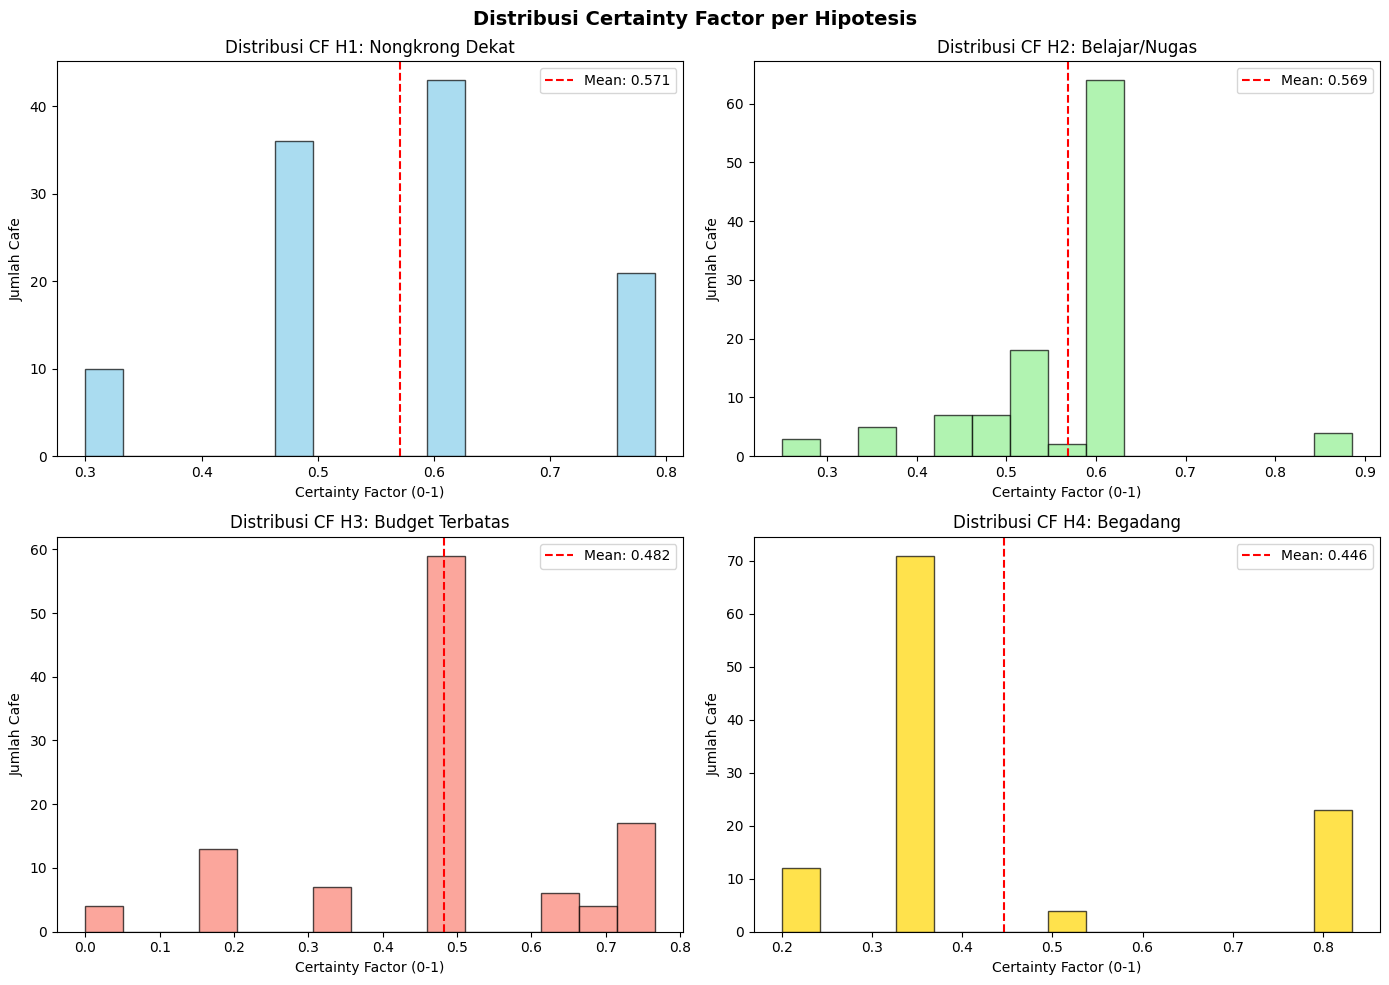

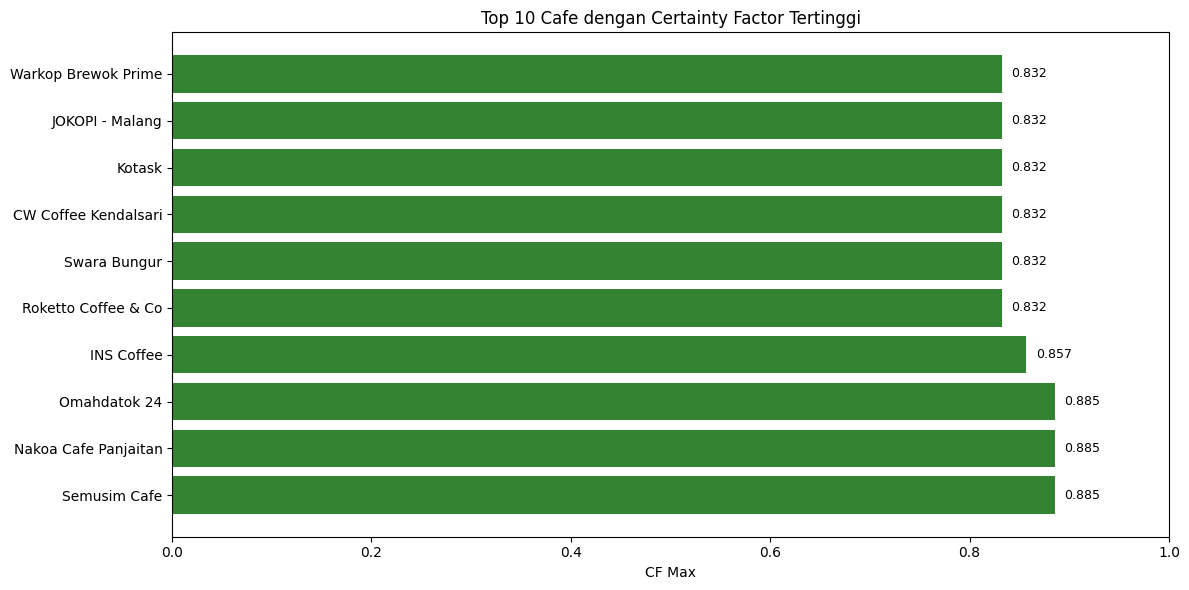

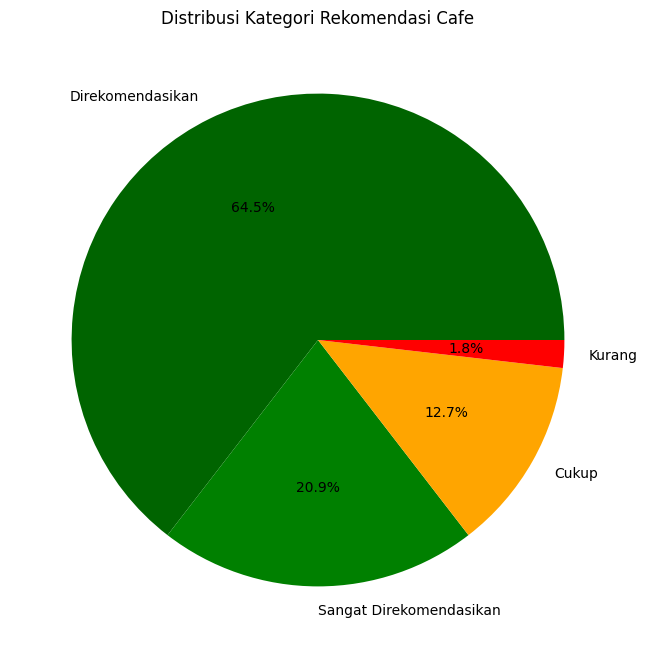

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

hypotheses = ['H1', 'H2', 'H3', 'H4']
titles = ['H1: Nongkrong Dekat', 'H2: Belajar/Nugas', 'H3: Budget Terbatas', 'H4: Begadang']
colors = ['skyblue', 'lightgreen', 'salmon', 'gold']

for idx, (hyp, title, color) in enumerate(zip(hypotheses, titles, colors)):
    ax = axes[idx//2, idx%2]
    ax.hist(df[f'CF_{hyp}'], bins=15, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(df[f'CF_{hyp}'].mean(), color='red', linestyle='--', label=f'Mean: {df[f"CF_{hyp}"].mean():.3f}')
    ax.set_title(f'Distribusi CF {title}')
    ax.set_xlabel('Certainty Factor (0-1)')
    ax.set_ylabel('Jumlah Cafe')
    ax.legend()

plt.suptitle('Distribusi Certainty Factor per Hipotesis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
top10 = df_ranking.head(10)
colors_bar = ['darkgreen' if cf >= 0.8 else 'green' if cf >= 0.6 else 'orange' for cf in top10['CF_Max']]
bars = plt.barh(range(len(top10)), top10['CF_Max'], color=colors_bar, alpha=0.8)
plt.yticks(range(len(top10)), [f"{name[:20]}..." if len(name) > 20 else name for name in top10['Nama']])
plt.xlabel('CF Max')
plt.title('Top 10 Cafe dengan Certainty Factor Tertinggi')
plt.xlim(0, 1)


for i, (bar, cf) in enumerate(zip(bars, top10['CF_Max'])):
    plt.text(cf + 0.01, i, f'{cf:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 8))
rekom_counts = df['Rekomendasi'].value_counts()
colors_pie = ['darkgreen', 'green', 'orange', 'red', 'darkred']
plt.pie(rekom_counts, labels=rekom_counts.index, autopct='%1.1f%%', colors=colors_pie[:len(rekom_counts)])
plt.title('Distribusi Kategori Rekomendasi Cafe')
plt.show()

## Analisis dan Kesimpulan

### Karakteristik Hasil Certainty Factor

Hasil perhitungan CF menunjukkan distribusi yang bervariasi dengan rentang **0.36 - 0.89**. Berikut ringkasan statistik per hipotesis:

| Hipotesis | Rentang CF | Cafe Tertinggi | Faktor Dominan |
|-----------|------------|----------------|----------------|
| H1: Nongkrong Dekat | 0.36 - 0.79 | Semusim Cafe, INS Coffee | Jarak ≤ 1 km |
| H2: Belajar/Nugas | 0.44 - 0.89 | 4 cafe dengan Working Space | Working Space (bobot 0.70) |
| H3: Budget Terbatas | 0.20 - 0.77 | Semusim Cafe, Kopi Studio 24 Sarangan | Harga Low + Rating ≥ 4.5 |
| H4: Begadang | 0.36 - 0.83 | 11 cafe dengan durasi ≥ 22 jam | Durasi Buka 22+ jam |

**Insight utama:** H2 menghasilkan CF tertinggi karena Working Space merupakan evidence langka (hanya 4 cafe) dengan bobot tertinggi. Sementara itu, H4 menunjukkan clustering pada 0.83 karena 11 cafe memenuhi kombinasi evidence identik.

---

### Profil Cafe Tertinggi

| Ranking | Nama Cafe | CF Max | Hipotesis Dominan | Keunggulan |
|---------|-----------|--------|-------------------|------------|
| 1 | Semusim Cafe | 0.89 | H2: Belajar | Working Space + Dekat + Murah |
| 2 | Nakoa Cafe Panjaitan | 0.89 | H2: Belajar | Working Space + Rating Tinggi |
| 3 | Omahdatok 24 | 0.89 | H2: Belajar | Working Space + 24 Jam |
| 4 | INS Coffee | 0.86 | H2: Belajar | Working Space + Dekat |
| 5 | Kalm Coffee Daily | 0.83 | H4: Begadang | 24 Jam + Fasilitas Lengkap |

---

### Kelebihan dan Kelemahan Model

| Aspek | Evaluasi |
|-------|----------|
| **Kelebihan** | • Tidak butuh data prior (vs Bayes)&lt;br&gt;• Transparan: user lihat rule yang aktif&lt;br&gt;• Incremental: bisa tambah evidence baru |
| **Kelemahan** | • Bobot CF ditentukan manual (subjektif)&lt;br&gt;• Asumsi evidence independen (mungkin berkorelasi)&lt;br&gt;• Clustering jika evidence identik |

---

### Perbandingan Keempat Metode

| Metode | Handle Uncertainty | Butuh Data Training | Interpretasi | Cocok untuk Kasus Ini |
|--------|-------------------|---------------------|--------------|----------------------|
| Forward Chaining | ❌ Tidak | ❌ Tidak | ⚠️ Sedang | Kurang (terlalu kaku) |
| Backward Chaining | ❌ Tidak | ❌ Tidak | ⚠️ Sedang | Kurang (goal terbatas) |
| Teorema Bayes | ✅ Ya | ✅ Banyak | ❌ Sulit | Kurang (prior tidak tersedia) |
| **Certainty Factor** | ✅ Ya | ❌ Tidak | ✅ Mudah | **✅ Paling Sesuai** |

---



### Visualisasi Hasil

Distribusi CF per hipotesis (Gambar 1) menunjukkan pola yang berbeda-beda. H2 menunjukkan distribusi skewed dengan puncak di 0.6, mengindikasikan bahwa sebagian besar cafe memenuhi evidence dasar (WiFi, Colokan, AC, Indoor) namun tidak memiliki Working Space yang menjadi pembeda utama. Sementara itu, H4 menunjukkan bimodal distribution yang jelas memisahkan cafe dengan durasi operasional panjang (≥22 jam) dari yang lebih pendek.

Top 10 ranking (Gambar 2) memperlihatkan adanya clustering nilai CF, dengan 6 cafe di posisi 5-10 memiliki CF identik 0.832 berdasarkan H4, dan 3 cafe teratas dengan CF 0.885 berdasarkan H2. Pie chart (Gambar 3) menunjukkan bahwa 64.5% cafe direkomendasikan untuk mahasiswa, dengan 20.9% masuk kategori sangat direkomendasikan.

---

### Kesimpulan

Certainty Factor dipilih sebagai model terbaik untuk sistem rekomendasi cafe karena:

1. **Mengakomodasi ketidakpastian** preferensi mahasiswa (dekat, murah, nyaman) 
2. **Transparan**: user dapat memahami mengapa cafe direkomendasikan
3. **Fleksibel**: bobot evidence dapat disesuaikan dengan kebutuhan domain